# Bonus Insights

The assignment asks: "what else can you see?" Beyond categorization and sentiment, I looked for insights that are valuable to a *specific stakeholder* and aren't obvious from looking at any single call in isolation.

I'm presenting three ideas:

1. **Incident Blast Radius Timeline** — fully implemented below.
2. **Churn-risk scoring from external/support calls** — described, not built (see bottom of notebook).
3. **Commitment / action-item follow-through tracking** — described, not built (see bottom of notebook).

I chose to fully build #1 because it's the most cross-functional and "leadership-pitch-able" of the three, it's genuinely novel (neither Task 1 nor Task 2 would surface it on their own), and this specific dataset happens to contain a real, traceable incident that makes for a concrete, non-contrived demo rather than a synthetic example.

## 1. Incident Blast Radius Timeline (fully implemented)

### The idea

Trace a single product incident as it ripples across **all three call types** — internal response, customer-facing escalations, and support tickets — on one unified timeline. Today these calls live in three different team silos (support sees tickets, sales/AM sees escalation calls, engineering sees war rooms/RCAs); no single view shows the *composite* cost of one bug.

### Who'd use this

A **PM or engineering leader** doing incident retros / prioritizing the next quarter's reliability work. "This pipeline bug generated 1 support ticket" undersells it. "This pipeline bug generated 20 calls across 8 customer accounts over 12 days, including two compliance-risk escalations with major accounts, and is now showing up in a competitive-threat assessment" is a very different argument for engineering investment.

### How it's built

1. **Candidate detection** (transparent, auditable rule): keyword match on call titles for incident-related language (e.g. "Detect Outage", "INCIDENT", "Pipeline Failure", or specific failure-mode language like "Alerts Not Firing", "Data Gaps").
2. **LLM confirmation + stage extraction**: for each candidate, the LLM confirms it's genuinely incident-related (filters out false-positive keyword matches), identifies which customer (if any) was affected, and classifies which stage of incident lifecycle the call represents (detection / customer_impact / escalation / remediation / resolution / retrospective).
3. **Output**: a structured timeline, ready to drop into a slide.

### How this generalizes beyond one hand-identified incident

In a production version, this wouldn't be a one-off script for one outage. The general version: (a) embed all call summaries, (b) cluster temporally-close + semantically-similar calls, (c) auto-flag any cluster spanning 2+ call types within a short time window as a candidate cross-functional incident, (d) run this same stage-extraction pipeline on it automatically. I didn't build the generic clustering version given the time-box, but the stage-extraction and timeline-rendering logic below is the reusable core of it.

In [1]:
import sys, os
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from load_data import load_all_transcripts
from outage_blast_radius import build_timeline, find_candidate_calls

sns.set_style("whitegrid")
df = load_all_transcripts()

candidates = find_candidate_calls(df)
print(f"{len(candidates)} keyword-candidate calls found:")
candidates[["call_id","start_time","call_type","title"]].sort_values("start_time")

16 keyword-candidate calls found:


,call_id,start_time,call_type,title
19,01KQ38C4101D6774F2F02331,2026-03-10 13:15:00+00:00,internal,INCIDENT: Detect Pipeline Failure - War Room
95,01KQEDB92E33CF9945A7F71B,2026-03-10 13:15:00+00:00,external,URGENT: Cobalt Software - Aegis Detect Dashboa...
33,01KQ46A9DE0AECB006D897A0,2026-03-11 11:00:00+00:00,internal,Detect Outage - Escalation Bridge
58,01KQ7BF0D56037FF89DC89B6,2026-03-11 17:45:00+00:00,support,Support Case #3266 - Trailhead Marketplace Det...
18,01KQ351E141926AB7CAB668D,2026-03-12 12:15:00+00:00,external,Aegis / Northstar Pharma - Urgent: Detect Outa...
11,01KQ2331EFD78BF3B1CAB747,2026-03-12 13:45:00+00:00,internal,Detect Outage - Customer Impact Assessment
15,01KQ2D93184912F0147315E7,2026-03-12 15:45:00+00:00,external,URGENT: Blackridge Investments - Complete Loss...
66,01KQ94C2B8B9B4668F3D3491,2026-03-13 10:30:00+00:00,support,Support Case #6573 - Ridgeline Logistics Detec...
94,01KQE110900B8A65D80AE694,2026-03-14 14:30:00+00:00,internal,Detect Outage - Root Cause Analysis
17,01KQ325BDEDEE927D2970775,2026-03-14 17:15:00+00:00,support,Support Case #5889 - Ridgeline Logistics Detec...


In [2]:
# NOTE: makes one LLM call per candidate (~20), takes under a minute
timeline = build_timeline(df)
timeline.to_csv("../outputs/incident_blast_radius_timeline.csv", index=False)
timeline[["call_id","start_time","call_type","incident_stage","customer_affected","one_line_summary"]]

Found 16 keyword-candidate calls for the incident.
  extracting 1/16: 01KQ03B0303900521BB089CA (Detect Outage - Remediation Plan Review)
  extracting 2/16: 01KQ2331EFD78BF3B1CAB747 (Detect Outage - Customer Impact Assessment)
  extracting 3/16: 01KQ2D93184912F0147315E7 (URGENT: Blackridge Investments - Complete Loss of )
  extracting 4/16: 01KQ325BDEDEE927D2970775 (Support Case #5889 - Ridgeline Logistics Detect La)
  extracting 5/16: 01KQ351E141926AB7CAB668D (Aegis / Northstar Pharma - Urgent: Detect Outage I)
  extracting 6/16: 01KQ38C4101D6774F2F02331 (INCIDENT: Detect Pipeline Failure - War Room)
  extracting 7/16: 01KQ3CE40428CCC5FF433FFC (Detect Outage - Post-Incident Review)
  extracting 8/16: 01KQ46A9DE0AECB006D897A0 (Detect Outage - Escalation Bridge)
  extracting 9/16: 01KQ5D47170D4828E89EDE37 (Support Case #7537 - Forge Industries Detect Recov)
  extracting 10/16: 01KQ7BF0D56037FF89DC89B6 (Support Case #3266 - Trailhead Marketplace Detect )
  extracting 11/16: 01KQ88B8EAEAA8

,call_id,start_time,call_type,incident_stage,customer_affected,one_line_summary
5,01KQ38C4101D6774F2F02331,2026-03-10 13:15:00+00:00,internal,escalation,None,War room call convened approximately 4 hours i...
14,01KQEDB92E33CF9945A7F71B,2026-03-10 13:15:00+00:00,external,detection,Cobalt Software,Cobalt Software's VP of Infrastructure called ...
7,01KQ46A9DE0AECB006D897A0,2026-03-11 11:00:00+00:00,internal,escalation,None,"Engineering, customer success, and support lea..."
9,01KQ7BF0D56037FF89DC89B6,2026-03-11 17:45:00+00:00,support,customer_impact,Trailhead Marketplace,Isaac Brennan from Trailhead Marketplace calle...
4,01KQ351E141926AB7CAB668D,2026-03-12 12:15:00+00:00,external,customer_impact,Northstar Pharma,Grace Yoon from Northstar Pharma expressed ser...
1,01KQ2331EFD78BF3B1CAB747,2026-03-12 13:45:00+00:00,internal,customer_impact,None,Internal team assessed widespread customer imp...
2,01KQ2D93184912F0147315E7,2026-03-12 15:45:00+00:00,external,customer_impact,Blackridge Investments,Julia Tran from Blackridge Investments escalat...
12,01KQ94C2B8B9B4668F3D3491,2026-03-13 10:30:00+00:00,support,customer_impact,Ridgeline Logistics,Ridgeline Logistics reported complete loss of ...
13,01KQE110900B8A65D80AE694,2026-03-14 14:30:00+00:00,internal,retrospective,None,The engineering team conducted a root cause an...
3,01KQ325BDEDEE927D2970775,2026-03-14 17:15:00+00:00,support,customer_impact,Ridgeline Logistics,Aegis support lead Priya Patel confirmed to Ri...


In [3]:
print(f"Total incident-related calls confirmed: {len(timeline)}")
print(f"Call types involved: {sorted(timeline['call_type'].unique())}")
print(f"Distinct customers affected: {timeline['customer_affected'].dropna().nunique()}")
print(f"Customers: {sorted(timeline['customer_affected'].dropna().unique())}")
print(f"Span: {timeline['start_time'].min()} to {timeline['start_time'].max()}")

Total incident-related calls confirmed: 15
Call types involved: ['external', 'internal', 'support']
Distinct customers affected: 7
Customers: ['Blackridge Investments', 'Cobalt Software', 'Forge Industries', 'Helix Data', 'Northstar Pharma', 'Ridgeline Logistics', 'Trailhead Marketplace']
Span: 2026-03-10 13:15:00+00:00 to 2026-03-18 16:30:00+00:00


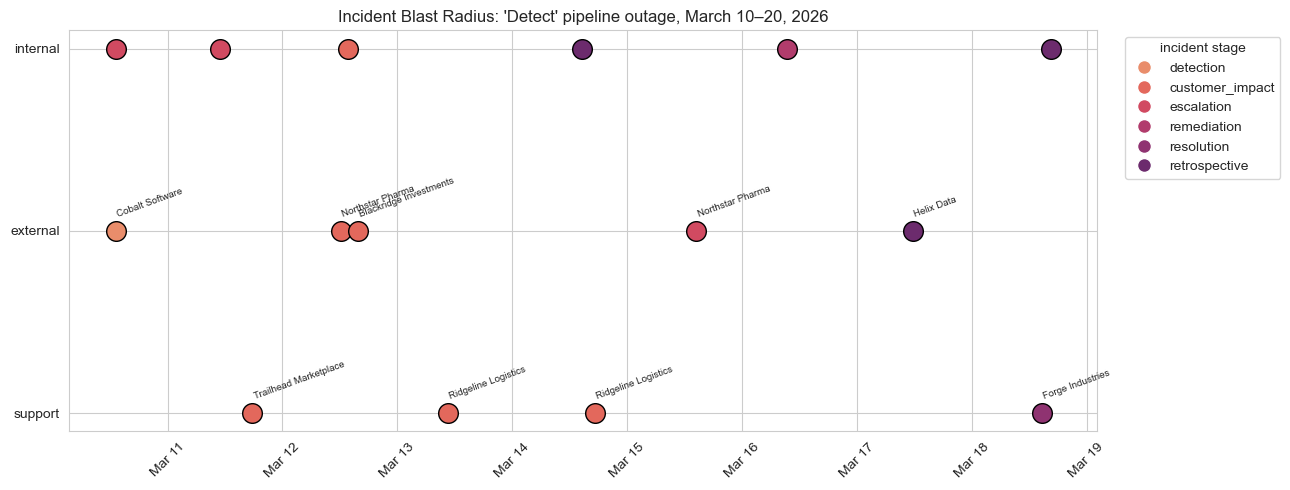

In [4]:
# Timeline visualization: one row per call type, dots colored by stage, sized by sentiment severity
stage_order = ["detection","customer_impact","escalation","remediation","resolution","retrospective"]
stage_colors = dict(zip(stage_order, sns.color_palette("flare", len(stage_order))))

fig, ax = plt.subplots(figsize=(13,5))
type_y = {"internal": 2, "external": 1, "support": 0}

for r in timeline.itertuples():
    y = type_y[r.call_type]
    color = stage_colors.get(r.incident_stage, "gray")
    size = 200 if pd.notna(r.baseline_sentiment_score) else 100
    ax.scatter(r.start_time, y, color=color, s=size, edgecolor="black", zorder=3)
    label = r.customer_affected if pd.notna(r.customer_affected) else ""
    ax.annotate(label, (r.start_time, y), textcoords="offset points", xytext=(0,10), fontsize=7, rotation=20)

ax.set_yticks(list(type_y.values()))
ax.set_yticklabels(list(type_y.keys()))
ax.set_title("Incident Blast Radius: 'Detect' pipeline outage, March 10–20, 2026")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)

# legend for stages
handles = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=stage_colors[s], markersize=10, label=s) for s in stage_order]
ax.legend(handles=handles, bbox_to_anchor=(1.02,1), loc="upper left", title="incident stage")

plt.tight_layout()
plt.savefig("../outputs/figures/incident_blast_radius_timeline.png", dpi=150)
plt.show()

### Reading the timeline

- The incident starts as an **internal war room** the same day an external customer (Cobalt Software) independently reports the dashboard is down — i.e. customers noticed before/as fast as the internal detection process flagged it, which is itself worth a callout.
- Over the next several days, **support tickets arrive from multiple unrelated customers** (Trailhead Marketplace, Ridgeline Logistics x2, Silverline Brands, Forge Industries) — different symptoms (latency, data gaps, false positives, alerts not firing), same root cause.
- Two **major accounts escalate directly** rather than going through support (Northstar Pharma, Blackridge Investments), both explicitly framing this as a compliance/threat-visibility risk — a more dangerous framing for a security/compliance vendor than a generic outage complaint.
- The incident closes out with a **recovery confirmation** support call and a **competitive threat assessment**, suggesting leadership is treating this as having created a window of vulnerability against competitors — connecting an engineering reliability issue directly to competitive/sales risk.

---
## 2. Churn-risk scoring from external/support calls (described, not built)

### The idea
Score every external/support call on a churn-risk index combining: customer sentiment trajectory across that account's call history (not just one call), frequency/recency of support tickets from the same account, explicit risk language (competitor mentions, contract/renewal hesitation, executive escalation), and whether commitments made to that customer in past calls were actually followed through on.

### Who'd use this
**Account/customer success management.** Rather than reactively finding out an account is at risk when they don't renew, this would surface a ranked, continuously-updated list of "accounts trending toward risk" based on what's actually said in calls — catching softer signals (hesitation, repeated minor complaints, going quiet) before they show up in a CRM health score.

### Why I didn't build it here
It needs **per-account history aggregation across multiple calls** (this dataset's accounts mostly appear in just 1-4 calls each, so per-account signal would be thin without more data — exactly the kind of thing the FAQ invites generating synthetic data for, but I prioritized fully building the blast-radius insight, which the existing data could support richly, over partially building a churn model on thin per-account history).

---
## 3. Commitment / action-item follow-through tracking (described, not built)

### The idea
The dataset's pre-existing `actionItems` field already captures commitments made on each call (e.g. "Jordan Whitfield: clean up the competitive deck... share before EOD tomorrow"). An insight worth building: track whether commitments made in one call are actually referenced as *done* in a later call with the same people/account, flagging commitments that seem to have gone stale.

### Who'd use this
**Anyone managing follow-through on customer commitments** — support leads (did we actually deliver the fix we promised?), account managers (did we send the deck we said we would?), and engineering managers (did the remediation we committed to in the war room actually happen by the date we said?).

### Why I didn't build it here
It requires reliably matching commitments across *separate* calls (e.g. matching "Jordan will share the deck by EOD" in Call A to language in Call B three days later confirming it happened) — a harder NLP linking problem than the other two insights, more prone to false matches without more careful prompt design and probably a larger sample to validate precision/recall against. A well-scoped follow-up rather than something to rush in the time-box.